# Unified Recommendation System: SLi-Rec with LightGCN Graph Embeddings

This notebook loads the SLi-Rec Amazon dataset, trains LightGCN for structural item embeddings, and integrates them into a custom SLi-Rec architecture for hybrid recommendation.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import random
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.get_logger().setLevel('ERROR')

import sys
sys.path.insert(0, '/home/users/mh720/workarea/roughrunapril24/recommenders')



from recommenders.models.deeprec.DataModel.ImplicitCF import ImplicitCF
from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN
from recommenders.models.deeprec.deeprec_utils import HParams, prepare_hparams
from recommenders.models.deeprec.io.sequential_iterator import SequentialIterator
from recommenders.models.deeprec.models.sequential.sli_rec import SLI_RECModel
from recommenders.utils.constants import SEED
from recommenders.datasets.amazon_reviews import download_and_extract, data_preprocessing

2025-04-16 02:15:28.990678: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 02:15:29.035212: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-16 02:15:29.035252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-16 02:15:29.036762: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-16 02:15:29.045136: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# Set absolute data path
data_dir = "/home/users/mh720/workarea/roughrunapril24/recommenders/examples/00_quick_start/tests/resources/deeprec/slirec"
reviews_name = "Movies_and_TV.jsonl" 
meta_name = "meta_Movies_and_TV.jsonl" 
reviews_file = os.path.join(data_dir, reviews_name)
meta_file = os.path.join(data_dir, meta_name)
train_file = os.path.join(data_dir, "train_data")
valid_file = os.path.join(data_dir, "valid_data")
test_file = os.path.join(data_dir, "test_data")
user_vocab = os.path.join(data_dir, "user_vocab.pkl")
item_vocab = os.path.join(data_dir, "item_vocab.pkl")
cate_vocab = os.path.join(data_dir, "category_vocab.pkl")

input_files = (
    reviews_file, meta_file, train_file, valid_file, test_file,
    user_vocab, item_vocab, cate_vocab
)

# Download and preprocess if needed
if not os.path.exists(train_file):
    #download_and_extract(reviews_name, reviews_file)
    #download_and_extract(meta_name, meta_file)
    data_preprocessing(
        reviews_file, meta_file, train_file, valid_file, test_file,
        user_vocab, item_vocab, cate_vocab,
        sample_rate=0.1,
        valid_num_ngs=4,
        test_num_ngs=9,
        is_history_expanding=True
    )


In [3]:
import pandas as pd
import os
from types import MethodType
from recommenders.models.deeprec.DataModel.ImplicitCF import ImplicitCF

# Load training data
cols = ["user", "item", "category", "time", "rating"]
df = pd.read_csv(train_file, sep='\t', header=None, names=cols)
df["rating"] = pd.to_numeric(df["rating"], errors='coerce').fillna(0).astype(float)

# Filter: Keep items with ≥ 5 interactions
item_counts = df['item'].value_counts()
popular_items = item_counts[item_counts >= 5].index
df = df[df['item'].isin(popular_items)].reset_index(drop=True)

# Filter: Keep users with ≥ 5 interactions
user_counts = df['user'].value_counts()
active_users = user_counts[user_counts >= 5].index
df = df[df['user'].isin(active_users)].reset_index(drop=True)

print("Filtered item count:", df['item'].nunique())
print("Filtered user count:", df['user'].nunique())
print("Filtered data shape:", df.shape)

# Create ImplicitCF model
data_model = ImplicitCF(df, col_user='user', col_item='item', col_rating='rating')


Filtered item count: 936
Filtered user count: 5
Filtered data shape: (5009, 5)


In [4]:
# ✅ Add item_pool manually (needed by train_loader)
data_model.item_pool = set(df["item"].unique())

# ✅ Patch train_loader to avoid IndexError
def safe_train_loader(self, batch_size):
    indices = list(self.interact_status.index)
    actual_batch_size = min(batch_size, len(indices))
    users = random.sample(indices, actual_batch_size)
    interact = self.interact_status.iloc[users]
    pos_items = interact[self.col_item + "_interacted"].apply(lambda x: random.choice(list(x)))
    neg_items = interact[self.col_item + "_interacted"].apply(lambda x: random.choice(
        list(self.item_pool - set(x))
    ))
    return users, pos_items.tolist(), neg_items.tolist()

from types import MethodType
data_model.train_loader = MethodType(safe_train_loader, data_model)


In [5]:

# Determine safe batch size
actual_batch_size = min(32, data_model.interact_status.shape[0])

lightgcn_hparams = {
    "learning_rate": 0.01,
    "embed_size": 32,
    "batch_size": actual_batch_size,
    "n_layers": 2,
    "decay": 1e-4,
    "eval_epoch": -1,
    "top_k": 10,
    "save_model": True,
    "save_epoch": 5,
    "metrics": ["precision"],
    "train_dir": "./checkpoints",
    "MODEL_DIR": "./checkpoints",
    "train_num_epochs": 5
}

hparams_gcn = HParams(lightgcn_hparams)
hparams_gcn.epochs = hparams_gcn.train_num_epochs

lightgcn = LightGCN(hparams=hparams_gcn, data=data_model)

# Debug prints
print("data_model.train shape:", data_model.train.shape)
print("data_model.interact_status shape:", data_model.interact_status.shape)
print("data_model.interact_status.index:", data_model.interact_status.index.tolist())

# Train LightGCN
lightgcn.fit()


Already create adjacency matrix.
Already normalize adjacency matrix.
Using xavier initialization.


2025-04-16 02:16:28.574645: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5
2025-04-16 02:16:28.578406: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled


data_model.train shape: (880, 3)
data_model.interact_status shape: (3, 2)
data_model.interact_status.index: [0, 1, 2]
Epoch 1 (train)1.3s: train loss = 0.03844 = (mf)0.03762 + (embed)0.00081
Epoch 2 (train)0.8s: train loss = 0.00139 = (mf)0.00031 + (embed)0.00108
Epoch 3 (train)0.9s: train loss = 0.00126 = (mf)0.00017 + (embed)0.00109
Epoch 4 (train)0.7s: train loss = 0.00118 = (mf)0.00014 + (embed)0.00104
Save model to path /home/users/mh720/workarea/roughrunapril24/recommenders/examples/00_quick_start/checkpoints/epoch_5
Epoch 5 (train)0.8s: train loss = 0.00111 = (mf)0.00013 + (embed)0.00098


In [4]:
#Debugging Block don't run
print("Train shape:", df.shape)
print("Unique users:", df['user'].nunique())
print("Unique items:", df['item'].nunique())
print("Ratings > 0:", (df['rating'] > 0).sum())


Train shape: (5009, 5)
Unique users: 5
Unique items: 936
Ratings > 0: 880


In [5]:
#Debugging Block don't run
print("Train shape:", data_model.train.shape)
print("Number of users in interact_status:", data_model.interact_status.shape[0])
print("data_model.n_users:", data_model.n_users)
print("data_model.n_users_in_train:", data_model.n_users_in_train)


Train shape: (880, 3)
Number of users in interact_status: 3
data_model.n_users: 5
data_model.n_users_in_train: 5


In [6]:
graph_item_embeddings = lightgcn.sess.run(lightgcn.ia_embeddings)
print("Graph item embeddings shape:", graph_item_embeddings.shape)


Graph item embeddings shape: (936, 32)


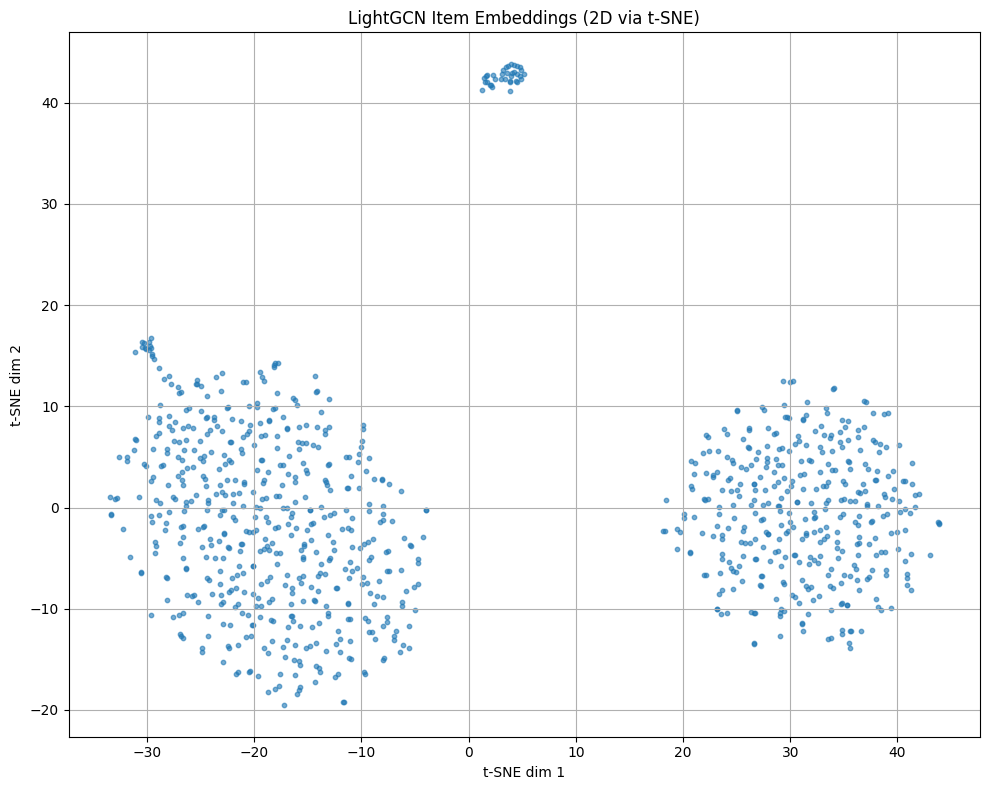

In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Optional: Load metadata if you want to color-code by category
# item_meta = pd.read_csv('your_item_metadata.csv')  # e.g., columns: item_id, category

# Get item ids from vocab if needed
import pickle
with open(item_vocab, 'rb') as f:
    item2id = pickle.load(f)
id2item = {v: k for k, v in item2id.items()}

# Step 1: Reduce dimensions using PCA first (optional, speeds up t-SNE)
pca = PCA(n_components=20)
pca_result = pca.fit_transform(graph_item_embeddings)

# Step 2: Then apply t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
item_emb_2d = tsne.fit_transform(pca_result)

# Step 3: Plot
plt.figure(figsize=(10, 8))
plt.scatter(item_emb_2d[:, 0], item_emb_2d[:, 1], alpha=0.6, s=10)
plt.title("LightGCN Item Embeddings (2D via t-SNE)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
class SLI_RECWithGCN(SLI_RECModel):
    def __init__(self, *args, graph_embeddings=None, **kwargs):
        self.graph_item_embeddings_init = graph_embeddings
        super().__init__(*args, **kwargs)

    def _get_pred(self, logit, method):
        if not hasattr(self, "input_dict") or "target_item" not in self.input_dict:
            return logit

        target_item = self.input_dict["target_item"]

        graph_item_embeddings = tf.constant(
            self.graph_item_embeddings_init,
            dtype=tf.float32,
            name="gcn_item_embedding"
        )
        graph_target_embed = tf.nn.embedding_lookup(graph_item_embeddings, target_item)

        fused_input = tf.concat([self.logit_input, graph_target_embed], axis=1)
        return self._fcn_net(fused_input, self.hparams.layer_sizes, scope="logit_fcn_gcn")



In [9]:
# SLi-Rec hyperparameters
yaml_file = '../../recommenders/models/deeprec/config/sli_rec.yaml'
hparams = prepare_hparams(
    yaml_file,
    embed_l2=0.0,
    show_step=100,
    save_model=True,
    epochs=3,
    batch_size=500,
    user_vocab=user_vocab,
    item_vocab=item_vocab,
    cate_vocab=cate_vocab,
    MODEL_DIR="./checkpoints/slirec_gcn"
)

# ✅ Ensure directory exists
os.makedirs(hparams.MODEL_DIR, exist_ok=True)

graph = tf.Graph()

# Verify content encoding consistency (fix for potential parsing issue)
with open(train_file, "r", encoding="utf-8") as f:
    preview = [f.readline() for _ in range(3)]
    print("\nPreview train_file content:")
    print(preview)

train_iter = SequentialIterator(hparams, graph, train_file)
valid_iter = SequentialIterator(hparams, graph, valid_file)
test_iter = SequentialIterator(hparams, graph, test_file)

print(f"Training for {hparams.epochs} epochs, batch_size={hparams.batch_size}")


Preview train_file content:
['1\tAG2L7H23R5LLKDKLBEF2Q3L2MVDA\tB001H1SVZC\tPrime Video\t1590639227074\tB06WVW16WY\tPrime Video\t1586999747540\n', '1\tAGXVBIUFLFGMVLATYXHJYL4A5Q7Q\tB0091VXC54\tPrime Video\t1443550066000\tB0002J58ME\tMovies & TV\t1146713492000\n', '1\tAGXVBIUFLFGMVLATYXHJYL4A5Q7Q\tB016JGYSRY\tPrime Video\t1445968640000\tB0002J58ME,B0091VXC54\tMovies & TV,Prime Video\t1146713492000,1443550066000\n']
Training for 3 epochs, batch_size=500


In [10]:
tf.reset_default_graph()
with graph.as_default():
    model = SLI_RECWithGCN(
        hparams,
        SequentialIterator,
        graph=graph,
        seed=SEED,
        graph_embeddings=graph_item_embeddings
    )

/home/users/mh720/workarea/roughrunapril24/recommenders/recommenders/models/deeprec/models/base_model.py:701: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  curr_hidden_nn_layer = tf.compat.v1.layers.batch_normalization(
2025-04-16 02:18:01.646697: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5


In [11]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    print("✅ Starting training...")
    model.fit(train_file, valid_file, valid_num_ngs=4)
    print("✅ Training complete!")

2025-04-16 02:18:04.837341: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5


✅ Starting training...

🔥 Starting Epoch 1 🔥


2025-04-16 02:20:12.765560: W tensorflow/c/c_api.cc:305] Operation '{name:'sequential/logit_fcn/nn_part/b_nn_output/Adam_1/Assign' id:6618 op device:{requested: '', assigned: ''} def:{{{node sequential/logit_fcn/nn_part/b_nn_output/Adam_1/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@sequential/logit_fcn/nn_part/b_nn_output"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](sequential/logit_fcn/nn_part/b_nn_output/Adam_1, sequential/logit_fcn/nn_part/b_nn_output/Adam_1/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


[Epoch 1] Step 100: total_loss=1.2642, data_loss=1.2373
[Epoch 1] Step 200: total_loss=1.2638, data_loss=1.2390
[Epoch 1] Step 300: total_loss=1.2795, data_loss=1.2566
[Epoch 1] Step 400: total_loss=1.2137, data_loss=1.1918
[Epoch 1] Step 500: total_loss=1.1586, data_loss=1.1376
[Epoch 1] Step 600: total_loss=1.1777, data_loss=1.1573
[Epoch 1] Step 700: total_loss=1.1906, data_loss=1.1707
[Epoch 1] Step 800: total_loss=1.1545, data_loss=1.1348
[Epoch 1] Step 900: total_loss=1.0997, data_loss=1.0803
[Epoch 1] Step 1000: total_loss=1.0918, data_loss=1.0725
[Epoch 1] Step 1100: total_loss=1.0652, data_loss=1.0462
[Epoch 1] Step 1200: total_loss=1.0352, data_loss=1.0162
[Epoch 1] Step 1300: total_loss=0.9577, data_loss=0.9390
[Epoch 1] Step 1400: total_loss=1.0015, data_loss=0.9829
[Epoch 1] Step 1500: total_loss=0.9957, data_loss=0.9772
[Epoch 1] Step 1600: total_loss=0.9308, data_loss=0.9125
[Epoch 1] Step 1700: total_loss=1.0299, data_loss=1.0116
[Epoch 1] Step 1800: total_loss=0.9845, 

In [12]:
results = model.run_eval(test_file, num_ngs=9)
print("📊 Test Results:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


📊 Test Results:
auc: 0.8781
logloss: 1.6729
mean_mrr: 0.7126
ndcg@2: 0.6719
ndcg@4: 0.7448
ndcg@6: 0.7690
group_auc: 0.8737


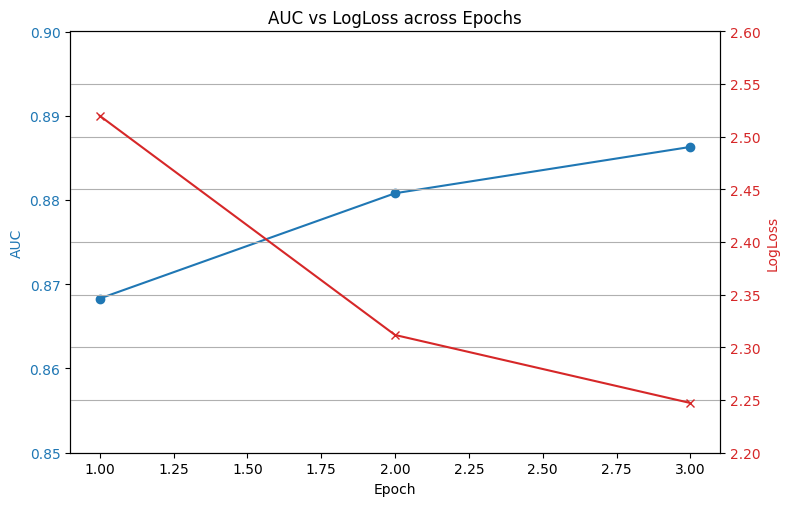

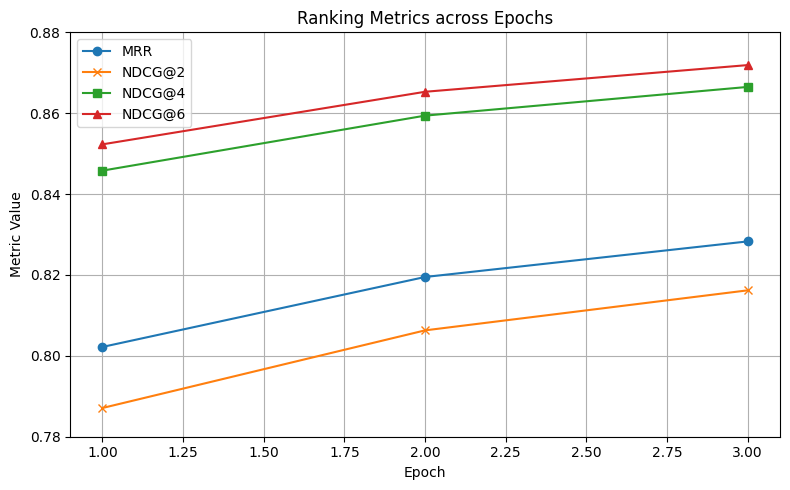

In [18]:
import matplotlib.pyplot as plt

# Evaluation metrics across 3 epochs
epochs = [1, 2, 3]
auc = [0.8683, 0.8808, 0.8863]
logloss = [2.52, 2.3118, 2.2472]
mrr = [0.8022, 0.8195, 0.8283]
ndcg_2 = [0.7871, 0.8063, 0.8162]
ndcg_4 = [0.8458, 0.8594, 0.8665]
ndcg_6 = [0.8523, 0.8653, 0.8719]

# ----------------------------
# Plot 1: AUC vs LogLoss with dual y-axis
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('AUC', color=color)
ax1.plot(epochs, auc, marker='o', color=color, label="AUC")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.85, 0.9)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('LogLoss', color=color)
ax2.plot(epochs, logloss, marker='x', color=color, label="LogLoss")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(2.2, 2.6)

fig.tight_layout()
plt.title("AUC vs LogLoss across Epochs")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2: MRR and NDCG metrics
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, mrr, label="MRR", marker='o')
plt.plot(epochs, ndcg_2, label="NDCG@2", marker='x')
plt.plot(epochs, ndcg_4, label="NDCG@4", marker='s')
plt.plot(epochs, ndcg_6, label="NDCG@6", marker='^')
plt.title("Ranking Metrics across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.ylim(0.78, 0.88)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
